# Semi-discrete convex order and Laguerre tessellation fitting : demo

This notebook describes the implementation and use of the method described in our paper:

*Semi-discrete convex order and Laguerre tessellation fitting* :   https://hal.science/hal-05008630


## 1. Laguerre tessellations

A Laguerre tessellation is a partition of $\mathbb{R}^d$ in $N$ cells defined by :

- **Generators**:  $X= (x_i)_i \in (\mathbb{R}^d)^N, ~  x_i \neq x_j  ~ \forall\, i\neq j \,, \quad $ 
- **Weights**:  $w= (w_i)_i \in \mathbb{R}^N$

The $i$th cell $L_i(w,X)$ is defined by

$$
		L_i(w,X) = \{ x \in \mathbb{R}^d  \,: \, |x-x_i|^2 -w_i \leq |x-x_j|^2 - w_j \,, ~\forall\, j \neq i\}
$$

In [5]:
# imports
from pysdot.domain_types import ConvexPolyhedraAssembly
from pysdot import PowerDiagram
from pysdot import OptimalTransport


import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 16,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 16,     # x/y labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20
})

# vtk
import vtk
from vtk.numpy_interface import dataset_adapter as dsa
from vtk.util.numpy_support import vtk_to_numpy

from ConvexOrderProjectionUtils import *


In [6]:

# basic power diagram
def make_pd( positions, weights ):
    domain = ConvexPolyhedraAssembly()
    domain.add_box([0, 0], [1, 1])
    
    pd = PowerDiagram(domain)
    pd.set_positions(positions)
    pd.set_weights(weights)
    return pd

In [7]:
# positions and weights
nb_diracs = 100
positions = np.random.rand(nb_diracs, 2)
weights = np.ones(nb_diracs)

# display
import ipywidgets
sl0 = ipywidgets.widgets.FloatSlider(min=1-0.1,max=1+0.1,step=0.001,value=1.0)
sl1 = ipywidgets.widgets.FloatSlider(min=1-0.1,max=1+0.1,step=0.001,value=1.0)
@ipywidgets.interact(w0=sl0, w1=sl1)
def disp(w0, w1):
    weights[ 0 ] = w0
    weights[ 1 ] = w1

    pd = make_pd( positions, weights )
    
    # shift + wheel to zoom in/out
    return pd.display_jupyter( disp_positions=False, disp_ids=False )


## 2. Motivation: Laguerre Tessellation Fitting

<br>
<div style="display: flex; justify-content: center; align-items: flex-start;">

<div style="text-align: center; margin-right: 50px;">
Electron backscatter diffraction (EBSD) single-phase steel [Tata Steel]<br><br>
<img src="EBSD_image.png" width="200">
</div>

<div style="text-align: center;">
X-ray diffraction Titanium alloy [McDonald et al. 2021]<br><br>
<img src="3dTiAl.png" width="250">
</div>

</div>

<br>

<div style="text-align: center;">
"Far field" 3D X-ray diffraction: <b>only</b> volumes, barycenters and orientations [Petrich et al. '19]
</div>

<br>

<div style="border: 2px solid #d9534f; padding: 10px; border-radius: 5px;">
<b>Laguerre tessellation fitting problem:</b> Given cell volumes $(v_i)_i$ and barycenters $(b_i)_i$:
<br>

$$
\text{Find Laguerre tessellation } (L_i)_i \text{ such that:} \quad |L_i| = v_i \quad \text{and} \quad \mathrm{bary}(L_i) \approx b_i.
$$

</div>

<br>

See [Bourne, Pearce, Roper 2025] for a first method based on <span style="color:red;">semi-discrete Optimal Transport</span> techniques


## 3. Semi-discrete Optimal Transport 

In [8]:
#@title Functions for solving the semi-discrete optimal transport problem

def init_w(x,om):
    """
    This function generates a weight vector w so that the Laguerre tessellation
    of the box om generated by the seeds x and the weights w has cells of
    positive area. It uses the rescaling method from Section 2.2 of the
    following paper:
    J. Meyron. Initialization procedures for discrete and semi-discrete
    optimal transport. Computer-Aided Design, 115:13–22, 2019.

    Inputs:
        x  - seeds, (n,2) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        w - weights of the Laguerre diagram, (n,) numpy array

    """

    # Centroid of the rectangular domain
    com = 0.5 * ( om.max_position() + om.min_position() )

    # Width and height of the rectangular domain
    Lx = om.max_position()[0] - om.min_position()[0]
    Ly = om.max_position()[1] - om.min_position()[1]

    # Define a dilation factor l and a translation t so that the transformed
    # seeds X = l*(x-com) + com = l*x + t lie inside the box. We choose to map
    # the 1st seed to the centre of mass (com) of the box. All the other seeds
    # are dilated about the centre of mass so that they lie inside the box.
    alpha = 0.49
    l = alpha * np.min([Lx,Ly]) / np.max(np.abs(x-x[0,:]))
    t = com - l*x[0,:]

    # The corresponding weight w for the original seeds
    # (see Lemma 2.1 in https://arxiv.org/pdf/2406.00871)
    w = -2.*np.sum(t*x,axis=1) - (l-1.)*np.sum(x*x,axis=1)

    return w

def solve_OT_problem(x,v,om):
    """
    This function uses pysdot to solve the semi-discrete optimal transport
    problem with source measure equal to the Lebesgue measure on the domain om
    and target measure equal to \sum_i v_i \delta_{x_i}.

    Inputs:
        x  - seeds, (n,2) numpy array
        v  - areas, (n,) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        w - weights of the Laguerre diagram, (n,) numpy array
        c - centroids of the Laguerre cells, (n,2) numpy array

    """

    # Error tolerance for the OT solver
    err_tol = 1e-4*np.min(v)

    # Generate initial weights such that all cells have positive area
    w0 = init_w(x,om)

    # Initialise the optimal transport problem
    ot = OptimalTransport(positions = x, masses = v, weights = w0, domain = om,
                          obj_max_dm = err_tol, verbosity = 0,
                          linear_solver = 'Scipy')

    # Solve the optimal transport problem
    ot.adjust_weights()

    # Get cell data
    c = ot.get_centroids() # centroids of the cells
    av = ot.pd.integrals() # areas of the cells
    w = ot.get_weights() # weights

    # Difference between the true areas and target areas
    dv = np.max( np.abs(v-av) )

    # Error message if dv > tolerance
    if dv > err_tol:
        print('Maximum error in volume ',dv)
        raise('Volume tolerance not met')

    return w, c


# Function for plotting the Laguerre tessellation
def plot_cells(x,w,om,ax):

    pd = PowerDiagram(positions=x,weights=w,domain=om)
    tmpvtkfile = "tmp.vtk";
    pd.display_vtk(tmpvtkfile)

    reader = vtk.vtkUnstructuredGridReader()
    reader.SetFileName(tmpvtkfile)
    reader.Update()
    data = reader.GetOutput()

    N = data.GetNumberOfCells()

    numpy_array_of_cells = dsa.WrapDataObject(data).Cells
    numpy_array_of_points = dsa.WrapDataObject(data).Points
    cells = vtk_to_numpy(numpy_array_of_cells)
    verts = vtk_to_numpy(numpy_array_of_points)

    idx = 0
    for k in range(N):
        nv = cells[idx]
        vidx = cells[idx+1:idx+nv+1]
        idx = idx+nv+1
        ax.plot(verts[vidx,0],verts[vidx,1],'k',linewidth=1)
        

In [9]:
Lx = 1.
Ly = 1.
n  = 10

# Generate the rectangular domain
om = ConvexPolyhedraAssembly()
om.add_box([0,0],[Lx,Ly])
Lmat = np.diag([Lx,Ly])

# Positions and masses
X0 = np.random.rand(n,2)@Lmat
v = np.ones(n)/n

# Solve OT problem
w,c = solve_OT_problem(X0,v,om)


pd = make_pd( X0, w )
    
pd.display_jupyter( disp_positions=True, disp_ids=False )

<IPython.core.display.Javascript object>

## 4. Semi-discrete convex order

Fix $\rho \in \mathcal{P}_2(\mathbb{R}^d)$ absolutely continuous and $v_i >0$ such that $\sum_{i=1}^N v_i = 1$.

<br>
<div style="border: 2px solid #d9534f; padding: 10px; border-radius: 5px;">
$$
\mathcal{C}_N(v,\rho) := \{ B = (b_1,\ldots,b_N) \in (\mathbb{R}^d)^N ~:~ \displaystyle \sum_{i=1}^N v_i \delta_{b_i} \preceq_C \rho\}
$$
</div>

$$
B\in \mathcal{C}_N(v,\rho) \iff \sum_i \varphi(b_i)v_i \leq \int_{\mathbb{R}^d} \varphi \,\mathrm{d} \rho \quad \forall\,\varphi:\mathbb{R}^d\rightarrow\mathbb{R} ~ \text{convex}
$$

### 4.1 Properties of $\mathcal{C}_N$

- $\mathcal{C}_N$ is a compact convex subset of $(\mathbb{R}^d)^N$. 
- If $B \in \mathcal{C}_N$ then 
$
\sum_i b_i v_i =\mathrm{bary}(\rho)
$. In particular, we have


$$ \mathrm{dim}(\mathcal{C}_N) = d(N-1)$$

### 4.2 Exposed points

**Weighted inner product**. We define: $~~\langle X,Y\rangle_v : = \sum_i \langle x_i , y_i\rangle v_i$

<br>

<div style="border: 2px solid #5cb85c; padding: 12px; border-radius: 5px; text-align: center">
Maximising $\langle \cdot, X \rangle_v$ over $\mathcal{C}_N(v,\rho)$  $\equiv$ Solving an OT problem from $\rho$ to $ \displaystyle \sum_{i=1}^N v_i \delta_{x_i}$
</div>

<br>


Let $X = (x_1, \ldots, x_N) \in (\mathbb{R}^d)^N$ with $x_i \neq x_j$ for $i \neq j$.


$$
B^* = \mathrm{argmax} \left\{ \langle B, X \rangle_v \;;\; B \in \mathcal{C}_N(v,\rho) \right\}
\iff
b_i^* = \mathrm{bary}_\rho \big( L_i(w^*, X) \big) ~~\forall i \,, \quad \text{where } w^* \text{ satisfies } \quad \rho(L_i(w^*,X)) = v_i ~~ \forall i
$$
<br>

In other words if $B^* = (b_i^*)_i$ satisfies $b_i^* = \mathrm{bary}_\rho \big( L_i(w^*, X) \big) $:
- $B^*$ is an exposed point of $\mathcal{C}_N$ $\leftarrow$ unique minimizer of a linear function on $\mathcal{C}_N$
- $X$ is the direction exposing $B^*$. 
- There exists a unique martingale $\theta \in \Pi\left(\rho, \sum_{i=1}^N \delta_{v_i} b_i^*\right)$, i.e. there exists a unique coupling $\theta \in \Pi\left(\rho, \sum_{i=1}^N \delta_{v_i} b_i^*\right)$,

$$
\int x \, d \theta_{b_i^*}(x)  = b_i^*\,, \quad \text{and this is given by }\quad \theta_{b_i^*} = \frac{1}{v_i} \rho|_{L_i(w^*,X)}
$$

## 5. Reconstruction of Laguerre tessellations from volumes and barycenters

### 5.1 Reconstruction problem and approximation

**Problem** Given $\overline{B}$ with $\overline{b}_i = \mathrm{bary}_\rho(L_i)$ and $(L_i)_i$ a Laguerre tessellation with volumes $\rho(L_i)= v_i$, we seek the unknown generators and weights of the tessellation.

**Approximate solution**

$$
B_\varepsilon = \mathrm{argmin} \left\{ \| (1+\varepsilon) \overline{B}- B \|_v ~;~ B \in \mathcal{C}_N\right\}\,, \quad X_\varepsilon  = (1+\varepsilon) \overline{B}- B
$$

### 5.2 Numerical solution via the Frank-Wolfe algorithm

**Input:** Initial guess $B^0 = \bar{B}$

<br>

<div style="line-height: 2; margin-bottom: 1.5em;">

**For** $n = 0,1,2,\dots$ until convergence:

<ol>
  <li>Compute $X^{n+1} \gets {(1+\varepsilon)\,\bar{B} - B^n}$</li>

  <li>Compute $w$ such that $\rho(L_i(w,X^n)) = v_i$ via damped Newton iterations:
    <ol>
      <li>Compute tessellation: $(L_i(w,X^n))_i$</li>
      <li>Compute: $\mathtt{A}_{ij} = \nabla_{w_j} \rho(L_i), \quad 
      \mathtt{b}_i = v_i - \rho(L_i \cap \Omega)$</li>
      <li>Solve linear system $\mathtt{A} \,\mathtt{x} = \mathtt{b}$ and update weights $w$.</li>
    </ol>
  </li>


  <li>Update $B^{n+1} \gets (\mathrm{bary}_\rho(L_i))_i$</li>
</ol>


In [10]:

def make_data_compatible(vi,bi,om):
    """
    This function modifies the target areas vi and target centroids bi so
    that they belong to the set $\mathcal{D}_n$ defined in Section 3 of this
    paper: https://arxiv.org/pdf/2406.00871

    Inputs:
        vi - initial target areas, (n,) numpy array
        bi - initial target centroids, (n,2) numpy array
        om - domain, pysdot ConvexPolyhedraAssembly (assumed to be a rectangle)

    Outputs:
        vr - target areas, (n,) numpy array
        br - target centroids, (n,2) numpy array

    vi and bi are rescaled so that vr and br satisfy sum(vr)=area(om) and
    and sum(vr*br)=area(om)*com, where com is the centroid of om.

    """

    # First make sure that the target areas sum to the total area of the domain
    total_vol = om.measure() # area of om
    vr = vi*total_vol/vi.sum()

    # Now makes sure that the centroid of the target centroids equals the
    # centroid of the domain
    com = 0.5*(om.max_position()+om.min_position()) # centroid on om
    br = bi + com - np.sum(vr.reshape(-1,1)*bi,axis=0)/total_vol
    return vr, br

def generate_perturbed_voronoi_data(Lx,Ly,n,x_seed=None,p_seed=None,amp=0):
    """
    This function generates synthetic data for the numerical experiments in
    Section 5.1 and 5.2 of the paper https://arxiv.org/pdf/2406.00871
    """

    # Generate the rectangular domain
    om = ConvexPolyhedraAssembly()
    om.add_box([0,0],[Lx,Ly])
    Lmat = np.diag([Lx,Ly])

    # Set the seed for the random number generator
    if x_seed is not None:
        np.random.seed(x_seed)

    # Generate a random collection of seeds
    X0 = np.random.rand(n,2)@Lmat

    # Compute the corresponding Voronoi diagram and the centroids and areas
    # of the Voronoi cells
    pd = PowerDiagram(positions=X0,weights=np.zeros(n),domain=om)
    b = pd.centroids() # centroids of the Voronoi cells
    v = pd.integrals() # areas of the Voronoi cells

    # Perturb the target centroids
    if p_seed is not None:
        np.random.seed(p_seed)
    angles = 2*np.pi*np.random.rand(n,1) # random angles
    unit_vec = np.hstack([np.cos(angles),np.sin(angles)])
    amps = amp*np.random.rand(n,1) # random amplitudes
    perts = unit_vec*amps # random perturbations
    br = b+perts # perturbation of the target centroids

    # Ensure data is compatible
    va, ba = make_data_compatible(v,br,om)
    return va, ba, om, X0

In [11]:

Lx = 1 # width of the rectangular box
Ly = 1 # height of the rectangular box

n = 20 # number of seeds

x_seed = 999 # seed for the random number generator

# Generate a random Voronoi diagram
v, b, om, X0 = generate_perturbed_voronoi_data(Lx, Ly, n, x_seed = x_seed,
                                               p_seed = None, amp = 0)

# Random initial guess for the optimisation method
Lmat=np.diag([Lx,Ly])
xinit=np.random.rand(n,2)@Lmat

In [12]:
#Convex order projection

t = 100 #regularization parameter t>>1
lowerbound = -np.sum(b*b*v.reshape((len(v),1)))/2/(t-1)/t
xt_history, fun_history =convex_order_projection_frank_wolfe(om, t/(t-1)*b, X0, masses = v,  niter= 4000, tol =1e-14)


seeds 20
Sucessfully imported sparse linear solver Scipy.
OT error 2.0184199060465782e-16
Frank-Wolfe gap :  0.018561153162967317
iteration  1 , function value  0.0010168994701800138Sucessfully imported sparse linear solver Scipy.
OT error 3.695744803958964e-16
Frank-Wolfe gap :  0.004443333417334987
iteration  2 , function value  0.0008669595116024176Sucessfully imported sparse linear solver Scipy.
OT error 1.6637300482913335e-16
Frank-Wolfe gap :  0.0017063718663374206
iteration  3 , function value  0.0006620244880729976Sucessfully imported sparse linear solver Scipy.
OT error 1.6758048310582263e-16
Frank-Wolfe gap :  0.0020389871406902675
iteration  4 , function value  0.0005808046638457144Sucessfully imported sparse linear solver Scipy.
OT error 2.366372021670376e-16
Frank-Wolfe gap :  0.0010290124332455212
iteration  5 , function value  0.00038961538277088373Sucessfully imported sparse linear solver Scipy.
OT error 3.97535644941589e-16
Frank-Wolfe gap :  0.0019844651896767395
iter

iteration  47 , function value  4.715047554622634e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.5610682143379613e-16
Frank-Wolfe gap :  4.890776739572474e-05
iteration  48 , function value  4.689708483782854e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.4801420686471056e-16
Frank-Wolfe gap :  2.353206604008291e-05
iteration  49 , function value  4.654931703055483e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8709497335744363e-16
Frank-Wolfe gap :  2.1739708582827575e-05
iteration  50 , function value  4.61979747337446e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.2153070828172284e-16
Frank-Wolfe gap :  2.2886074287207032e-05
iteration  51 , function value  4.5825432443166226e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.872075286230658e-16
Frank-Wolfe gap :  2.3012033913524095e-05
iteration  52 , function value  4.5594340909048594e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.590044395

iteration  94 , function value  3.6778613624101976e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2818479689276e-16
Frank-Wolfe gap :  4.776075288800467e-06
iteration  95 , function value  3.672884798970973e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.2314134513771935e-16
Frank-Wolfe gap :  6.497399161538704e-06
iteration  96 , function value  3.6698041720591764e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8147769660596383e-16
Frank-Wolfe gap :  4.021392480198193e-06
iteration  97 , function value  3.654383269370074e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9783644736240814e-16
Frank-Wolfe gap :  1.729694026867779e-05
iteration  98 , function value  3.647394724023484e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9693696090750078e-16
Frank-Wolfe gap :  4.916962563423011e-06
iteration  99 , function value  3.643464705289315e-05Sucessfully imported sparse linear solver Scipy.
OT error 3.0738521708404

OT error 2.9851486299806154e-16
Frank-Wolfe gap :  1.1037410914451089e-05
iteration  141 , function value  3.439529280844439e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.4478816905874435e-16
Frank-Wolfe gap :  4.8149164960797795e-06
iteration  142 , function value  3.4379380118178704e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.2138123423172857e-16
Frank-Wolfe gap :  1.8247523149028358e-06
iteration  143 , function value  3.436628284424348e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9340610888756946e-16
Frank-Wolfe gap :  1.5977635700018448e-06
iteration  144 , function value  3.435730583264123e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.314816072345342e-16
Frank-Wolfe gap :  1.455445075901366e-06
iteration  145 , function value  3.434768692199238e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.6777789532539506e-16
Frank-Wolfe gap :  1.5989953896448377e-06
iteration  146 , function value  3.4339320

iteration  187 , function value  3.364485174515366e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2743135077365934e-16
Frank-Wolfe gap :  2.8317941704530944e-06
iteration  188 , function value  3.363636202565985e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8578758849409054e-16
Frank-Wolfe gap :  8.1314221934625e-07
iteration  189 , function value  3.363228675657261e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8306264869907906e-16
Frank-Wolfe gap :  4.4719027337611705e-07
iteration  190 , function value  3.3624719824264365e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.391041175080521e-16
Frank-Wolfe gap :  8.299923900487588e-07
iteration  191 , function value  3.3621623272757836e-05Sucessfully imported sparse linear solver Scipy.
OT error 3.049180551913552e-16
Frank-Wolfe gap :  3.663876636100322e-07
iteration  192 , function value  3.359441107888071e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.377576

...

iteration  327 , function value  3.328578006260248e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.353876577137697e-16
Frank-Wolfe gap :  1.0364015091476965e-08
iteration  328 , function value  3.3285681736270054e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.711518129156076e-16
Frank-Wolfe gap :  7.073977160533863e-09
iteration  329 , function value  3.328563997599797e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.4260914705199837e-16
Frank-Wolfe gap :  5.968702067420325e-09
iteration  330 , function value  3.328559617057199e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9571071530548776e-16
Frank-Wolfe gap :  6.84713094697908e-09
iteration  331 , function value  3.32855681797703e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.5073389509024736e-16
Frank-Wolfe gap :  4.877758597268522e-09
iteration  332 , function value  3.328550657211334e-05Sucessfully imported sparse linear solver Scipy.
OT error 3.08050209

OT error 3.195860207826214e-16
Frank-Wolfe gap :  5.089581578037587e-09
iteration  374 , function value  3.328247191622239e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.0894778472913438e-16
Frank-Wolfe gap :  1.614437328911669e-09
iteration  375 , function value  3.3282465749967555e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.1204998935805272e-16
Frank-Wolfe gap :  1.1848628353396005e-09
iteration  376 , function value  3.3282451707342155e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.7051767047891423e-16
Frank-Wolfe gap :  2.723131073766024e-09
iteration  377 , function value  3.3282446104560076e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.3681517030061724e-16
Frank-Wolfe gap :  1.098568815754479e-09
iteration  378 , function value  3.328242119079841e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.6465905799975523e-16
Frank-Wolfe gap :  4.792487034544069e-09
iteration  379 , function value  3.328241329

iteration  420 , function value  3.3281458504401596e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8686965944356937e-16
Frank-Wolfe gap :  8.639265258323394e-11
iteration  421 , function value  3.3281458171451335e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.869984434939641e-16
Frank-Wolfe gap :  4.879835441595578e-11
iteration  422 , function value  3.3281452580951443e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2200237566478832e-16
Frank-Wolfe gap :  8.237780105864262e-10
iteration  423 , function value  3.328145112259377e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9278273188224606e-16
Frank-Wolfe gap :  2.1630067859797384e-10
iteration  424 , function value  3.328145067192567e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.995478737461029e-16
Frank-Wolfe gap :  6.635432810785613e-11
iteration  425 , function value  3.328145038269867e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.8534

OT error 1.9818598870690056e-16
Frank-Wolfe gap :  2.369421656366729e-11
iteration  467 , function value  3.328141380436871e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.5099146816391145e-16
Frank-Wolfe gap :  7.008470883821358e-12
iteration  468 , function value  3.328141378495912e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.1219185492735665e-16
Frank-Wolfe gap :  3.7128902603390004e-12
iteration  469 , function value  3.328141293552746e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.7069405747218524e-16
Frank-Wolfe gap :  1.6232906182713252e-10
iteration  470 , function value  3.328141272094198e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.4906766601027957e-16
Frank-Wolfe gap :  4.115541223616524e-11
iteration  471 , function value  3.3281412663641446e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.410095345269318e-16
Frank-Wolfe gap :  1.095767012235934e-11
iteration  472 , function value  3.3281412644

iteration  513 , function value  3.328141130444344e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.5973537908730046e-16
Frank-Wolfe gap :  1.2955607508864947e-12
iteration  514 , function value  3.328141127893743e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.5815741357620183e-16
Frank-Wolfe gap :  4.9474028810118265e-12
iteration  515 , function value  3.3281411270591464e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.3670512539044367e-16
Frank-Wolfe gap :  1.6182294952031204e-12
iteration  516 , function value  3.3281411262975486e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.695151273586779e-16
Frank-Wolfe gap :  1.4773865581178436e-12
iteration  517 , function value  3.32814112538813e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.3011255664322427e-16
Frank-Wolfe gap :  1.7643727179658035e-12
iteration  518 , function value  3.3281411247269564e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.

Text(0.5, 1.0, 'Reconstruction')

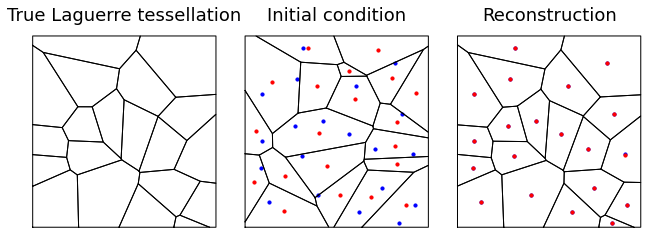

In [13]:
# Plot the results

# Plot the true Laguerre diagram
fig, (ax1,ax2,ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (9,3.5), layout = 'tight')
plot_cells(X0,np.zeros(n),om,ax1)
ax1.axis('off')
ax1.set_title('True Laguerre tessellation')


# Plot the recovered Laguerre diagram with CO
Z = xinit#t[-1]/(t[-1]-1)*b - np.ones(b.shape)*.5
w, c = solve_OT_problem(Z,v,om)
plot_cells(Z,w,om,ax2)
ax2.axis('off')
ax2.scatter(b[:,0],b[:,1],color='b',s=10) # target centroids in blue
ax2.scatter(c[:,0],c[:,1],color='r',s=10) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Initial condition')




# Plot the recovered Laguerre diagram with CO
Z = t/(t-1)*b - xt_history[-1]
w, c = solve_OT_problem(Z,v,om)
plot_cells(Z,w,om,ax3)
ax3.axis('off')
ax3.scatter(b[:,0],b[:,1],color='b',s=10) # target centroids in blue
ax3.scatter(c[:,0],c[:,1],color='r',s=10) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax3.set_title('Reconstruction')

#plt.savefig('laguerre_fw.png',dpi=300)


Let us check the evolution of the objective $f(B)$ along the iterations: 

$$
f(B) = \| B - (1+\varepsilon) \overline{B}\|
$$

Text(0, 0.5, '$f(B^k) - f(B^*)$')

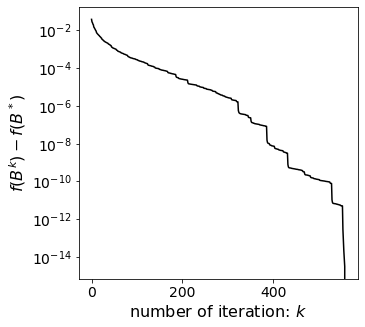

In [14]:


fig,ax = plt.subplots(figsize=(5,5))
ax.semilogy(np.sqrt(fun_history) - np.min(np.sqrt(fun_history)),'k-',linewidth=1.5,label = '$(1)$')
ax.set_xlabel('number of iteration: $k$')
ax.set_ylabel('$f(B^k) - f(B^*)$')



### 5.3 Recovery of aligned seeds


In [15]:
n =40
coords0= np.linspace(0,1,n)
x0, y0 = np.meshgrid(coords0,coords0)
positions = np.zeros((n**2,2))
positions[:,0] = x0.flatten()
positions[:,1] = y0.flatten()
flag_cross = np.logical_or(np.logical_and(positions[:,0]>.33,positions[:,0]<0.67),np.logical_and(positions[:,1]<.67,positions[:,1]>.33))
flag_center = np.logical_or( np.logical_or(positions[:,0]<.33,positions[:,0]>0.67),np.logical_or(positions[:,1]>.67,positions[:,1]<.33))
flag_cross = np.logical_and(flag_cross,flag_center)

#flag_cross = np.logical_and((positions[:,0]-.5)**2 + (positions[:,1]-.5)**2<.35**2,(positions[:,0]-.5)**2 + (positions[:,1]-.5)**2>.21**2)

Y = positions[flag_cross,:].copy()
masses = np.ones(len(Y[:,0]))#np.random.rand(len(Y[:,0]))+.2
masses = masses/np.sum(masses)

w,c = solve_OT_problem(Y,masses,om)
xinit=np.random.rand(len(Y[:,0]),2)@Lmat
t = 100

#Initial condition 1
#w_init,c_init = solve_OT_problem(xinit,masses,om)

#Initial condition 2
xinit = c.copy()
c_init = c.copy()

xt_history, fun_history =convex_order_projection_frank_wolfe(om, t/(t-1)*c, c_init, masses = masses,  niter= 1000,tol =1e-16)



seeds 728
Sucessfully imported sparse linear solver Scipy.
OT error 1.398895256398967e-13
Frank-Wolfe gap :  2.2100678741730585e-07
iteration  1 , function value  3.399002778910631e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.6568883877220007e-15
Frank-Wolfe gap :  4.2996636997240943e-07
iteration  2 , function value  3.398870948654992e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.190194024965229e-15
Frank-Wolfe gap :  1.7607012032941262e-07
iteration  3 , function value  3.3987480091384506e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.378107300060324e-11
Frank-Wolfe gap :  2.7585242471675216e-07
iteration  4 , function value  3.3986591460833424e-05Sucessfully imported sparse linear solver Scipy.
OT error 8.248749444258132e-13
Frank-Wolfe gap :  2.130481149041337e-07
iteration  5 , function value  3.398581037497731e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.65083257640389e-13
Frank-Wolfe gap :  2.204237873099728e-0

iteration  47 , function value  3.3966196644079925e-05Sucessfully imported sparse linear solver Scipy.
OT error 8.620994523142736e-13
Frank-Wolfe gap :  1.193651313930129e-07
iteration  48 , function value  3.3965867465206936e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.657558686130744e-14
Frank-Wolfe gap :  1.2346249782928882e-07
iteration  49 , function value  3.3965541705317346e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.0166273930243362e-12
Frank-Wolfe gap :  1.1745427070589247e-07
iteration  50 , function value  3.396521981645329e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2652405329632543e-13
Frank-Wolfe gap :  1.2136328922868856e-07
iteration  51 , function value  3.396490003330521e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.4800186477466326e-12
Frank-Wolfe gap :  1.1577776740243316e-07
iteration  52 , function value  3.3964581595565235e-05Sucessfully imported sparse linear solver Scipy.
OT error 4.324005

iteration  94 , function value  3.395325140084706e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2797939344482128e-15
Frank-Wolfe gap :  9.095618390940436e-08
iteration  95 , function value  3.395301909976008e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2728510417178379e-15
Frank-Wolfe gap :  8.850318173698153e-08
iteration  96 , function value  3.395278862473976e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2203822227814921e-15
Frank-Wolfe gap :  8.987522445575454e-08
iteration  97 , function value  3.3952558740764244e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.4292222317363507e-15
Frank-Wolfe gap :  8.768993676637775e-08
iteration  98 , function value  3.3952330880556166e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.3253094000934547e-15
Frank-Wolfe gap :  8.880413130046689e-08
iteration  99 , function value  3.3952104039065194e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.343443552

OT error 1.3393886450980518e-15
Frank-Wolfe gap :  7.189783817279882e-08
iteration  141 , function value  3.3943686008001134e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2031019403193905e-15
Frank-Wolfe gap :  7.085892948430633e-08
iteration  142 , function value  3.3943508789640326e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2916100617334819e-15
Frank-Wolfe gap :  7.120241626394876e-08
iteration  143 , function value  3.3943332394609474e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.3023804390138107e-15
Frank-Wolfe gap :  7.02385083566232e-08
iteration  144 , function value  3.394315740389806e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2430489637080525e-15
Frank-Wolfe gap :  7.04842256691154e-08
iteration  145 , function value  3.394298309437733e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.0802612862614334e-15
Frank-Wolfe gap :  6.962597447565599e-08
iteration  146 , function value  3.39428094411

iteration  187 , function value  3.393643544821813e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.249055442511606e-12
Frank-Wolfe gap :  5.8204857383440746e-08
iteration  188 , function value  3.393629663501261e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.193861462257712e-15
Frank-Wolfe gap :  5.8090944448782086e-08
iteration  189 , function value  3.3936158455025e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.1173244214304897e-12
Frank-Wolfe gap :  5.7758196986582475e-08
iteration  190 , function value  3.3936020647370256e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.2324048596882997e-15
Frank-Wolfe gap :  5.765074025368904e-08
iteration  191 , function value  3.3935883152888324e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.975320141718707e-12
Frank-Wolfe gap :  5.741913250268835e-08
iteration  192 , function value  3.393574667970501e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.032586

...

iteration  792 , function value  3.39072157967736e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.680604787136577e-13
Frank-Wolfe gap :  9.579279516167719e-09
iteration  793 , function value  3.390720527699102e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.672894577454901e-13
Frank-Wolfe gap :  1.011052120141255e-08
iteration  794 , function value  3.3907194150887525e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.664181805831045e-13
Frank-Wolfe gap :  9.803143668296463e-09
iteration  795 , function value  3.3907183515032623e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.656674292199972e-13
Frank-Wolfe gap :  9.840438759302107e-09
iteration  796 , function value  3.390717275777598e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.648390457913586e-13
Frank-Wolfe gap :  9.846398212388345e-09
iteration  797 , function value  3.3907162044092756e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.639833073

iteration  839 , function value  3.390675500474431e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.902414060813279e-13
Frank-Wolfe gap :  8.787816549231006e-09
iteration  840 , function value  3.3906746052813844e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.887471010906596e-13
Frank-Wolfe gap :  9.155373871162118e-09
iteration  841 , function value  3.390673673892126e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.871892546883541e-13
Frank-Wolfe gap :  8.974073029880197e-09
iteration  842 , function value  3.390672795882634e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.857252306908539e-13
Frank-Wolfe gap :  8.807938308717525e-09
iteration  843 , function value  3.3906719218481175e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.843324732945986e-13
Frank-Wolfe gap :  8.953443370918063e-09
iteration  844 , function value  3.390671035158641e-05Sucessfully imported sparse linear solver Scipy.
OT error 5.827909083

iteration  886 , function value  3.3906368844325786e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.5238074093896901e-15
Frank-Wolfe gap :  8.36537634095413e-09
iteration  887 , function value  3.390636092318451e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.86546376492565e-15
Frank-Wolfe gap :  8.244609374464044e-09
iteration  888 , function value  3.390635327314382e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9915486330800597e-15
Frank-Wolfe gap :  8.22381107559328e-09
iteration  889 , function value  3.390634587503102e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.5594780503421805e-15
Frank-Wolfe gap :  7.982853319042049e-09
iteration  890 , function value  3.3906338446034785e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9308069174065985e-15
Frank-Wolfe gap :  8.309789791216151e-09
iteration  891 , function value  3.3906330654226964e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.7925969

iteration  933 , function value  3.3906040610015286e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.955694108839516e-15
Frank-Wolfe gap :  7.540326159821635e-09
iteration  934 , function value  3.390603412718228e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.1256020809597586e-15
Frank-Wolfe gap :  7.558436619241529e-09
iteration  935 , function value  3.390602758107853e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.125311804571393e-15
Frank-Wolfe gap :  7.587597793309309e-09
iteration  936 , function value  3.39060210567991e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.9111317159628635e-15
Frank-Wolfe gap :  7.517476902142664e-09
iteration  937 , function value  3.390601464842841e-05Sucessfully imported sparse linear solver Scipy.
OT error 1.951343985741428e-15
Frank-Wolfe gap :  7.48577424423244e-09
iteration  938 , function value  3.3906008190511315e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.276096956

OT error 1.7319615219281409e-15
Frank-Wolfe gap :  7.005550046350489e-09
iteration  980 , function value  3.390575959631189e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.267608416085789e-15
Frank-Wolfe gap :  7.108645256202582e-09
iteration  981 , function value  3.390575372373548e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.593055444351387e-15
Frank-Wolfe gap :  7.0925546123181384e-09
iteration  982 , function value  3.390574810557322e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.4293331441385546e-15
Frank-Wolfe gap :  6.921356425844313e-09
iteration  983 , function value  3.3905742777486736e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.0160834523567002e-15
Frank-Wolfe gap :  6.8663427037776e-09
iteration  984 , function value  3.390573739180805e-05Sucessfully imported sparse linear solver Scipy.
OT error 2.4252591172362917e-15
Frank-Wolfe gap :  6.928137110124833e-09
iteration  985 , function value  3.39057317698768

0.05679265710003191


Text(0.5, 1.0, 'Reconstruction (FW)')

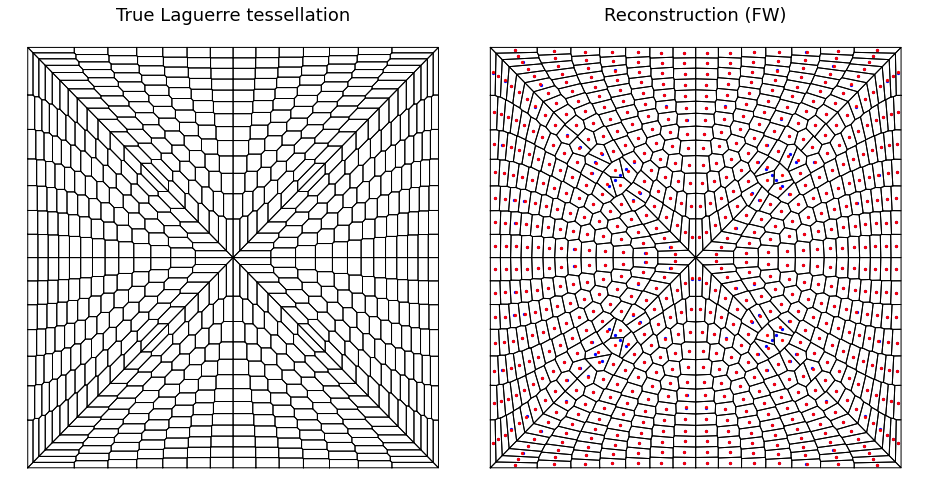

In [16]:

# Plot the true Laguerre diagram
f, (ax1,ax2) = plt.subplots(nrows = 1, ncols =2, figsize = (13,7), layout = 'tight')
w,b = solve_OT_problem(Y,masses,om)
plot_cells(Y, w,om,ax1)
ax1.axis('off')
ax1.set_title('True Laguerre tessellation')


# Plot the recovered Laguerre diagram with CO
Z0 = (t/(t-1)*b - xt_history[-1])
w, c = solve_OT_problem(Z0,masses,om)
plot_cells(Z0,w,om,ax2)
ax2.axis('off')
ax2.scatter(b[:,0],b[:,1],color='b',s=5) # target centroids in blue
ax2.scatter(c[:,0],c[:,1],color='r',s=5) # centroids of the recovered cells in red
if b.shape == c.shape: diff = np.sqrt(np.sum((b-c)**2))
else: diff = 1000
print(diff)
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Reconstruction (FW)')



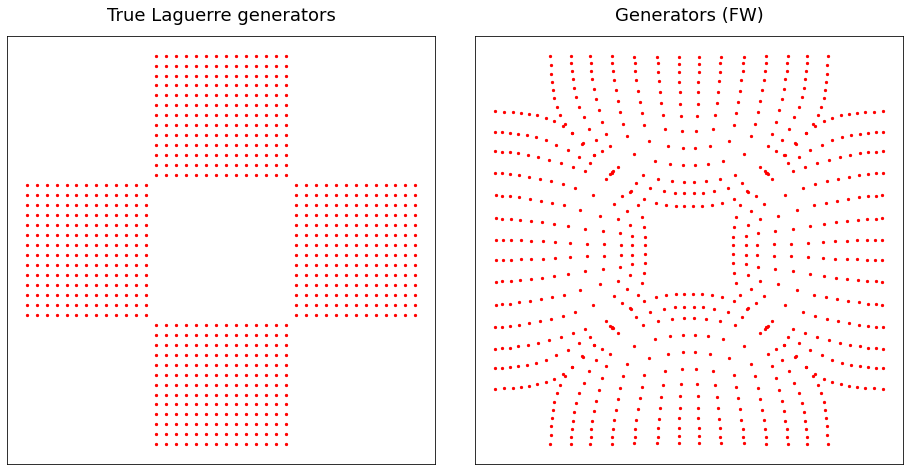

In [17]:

# Plot the true Laguerre diagram
f, (ax1,ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13,7))#, layout = 'tight')

#f.subplots_adjust(wspace=.1, hspace=.1)#,left=0.1,top=0.9,right=0.9,bottom=0.1)  # Adjust horizontal and vertical spacing
f.tight_layout(pad=.01) 

#f.subplots_adjust(wspace=1, hspace=1)
ax1.scatter(Y[:,0],Y[:,1],color='r',s=5) # target centroids in blue
ax1.set_title('True Laguerre generators',pad= 15)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect('equal', adjustable='box')  # Make the axes square

ax2.scatter(Z0[:,0],Z0[:,1],color='r',s=5) # target centroids in blue
#ax2.axis('off')
#ax3.set_title('Convex order. Deviation: {:.3f}'.format(diff) )
ax2.set_title('Generators (FW)',pad= 15)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_aspect('equal', adjustable='box')  # Make the axes square





### 5.4  EBSD data

In [19]:
EBSD = np.loadtxt("EBSD_data.txt")

# Number of grains
n = np.shape(EBSD)[0]
print('Number of grains =',n)

# Areas of the grains
target_areas = EBSD[:,3]

# Centroids of the grains - we will use these as the seeds
target_centroids = EBSD[:,1:3]

# Area and size of the box
total_area = target_areas.sum()
target_centroids = target_centroids/np.sqrt(total_area)
target_areas = target_areas/total_area
total_area = 1.

box_size = np.sqrt(total_area)
print('Box size in microns =',box_size)

# The rectangular domain
OmegaEBSD = ConvexPolyhedraAssembly()
OmegaEBSD.add_box([0,0],[box_size,box_size])

# Ensure that that the target areas sum to the area of the box
target_areas = target_areas*box_size**2/total_area
v, b = make_data_compatible(target_areas,target_centroids,OmegaEBSD)

Number of grains = 243
Box size in microns = 1.0


In [20]:
# Code to perform the numerical experiment in Section 5.3
# of https://arxiv.org/pdf/2406.00871

# Initial guess for the optimisation method
xinit = b # target centroids

# Tolerances for the optimisation method
ptol = 1e-8
maxiter = 10000 # maximum number of iterations
R0 =1.#250
# Fit a Laguerre diagram to the EBSD data by minimising f

t = 10 #regularization parameter t>>1
xt_history, fun_history = convex_order_projection_frank_wolfe(OmegaEBSD, t/(t-1)*b, .5*np.ones(b.shape), R0=R0, masses = v,  niter= 500, tol =1e-9)

seeds 243
Sucessfully imported sparse linear solver Scipy.
OT error 8.60053377092802e-13
Frank-Wolfe gap :  0.18309221429951666
iteration  1 , function value  0.0041135739063293385Sucessfully imported sparse linear solver Scipy.
OT error 1.2826413766222858e-15
Frank-Wolfe gap :  0.0001378452755415803
iteration  2 , function value  0.004110627954284416Sucessfully imported sparse linear solver Scipy.
OT error 6.735438004489024e-16
Frank-Wolfe gap :  4.0402184308716845e-05
iteration  3 , function value  0.004109548813231973Sucessfully imported sparse linear solver Scipy.
OT error 5.771760494530597e-16
Frank-Wolfe gap :  1.7793923664098834e-05
iteration  4 , function value  0.0041084425214745575Sucessfully imported sparse linear solver Scipy.
OT error 5.199445983017094e-16
Frank-Wolfe gap :  1.1775918340317322e-05
iteration  5 , function value  0.004107544183205771Sucessfully imported sparse linear solver Scipy.
OT error 1.802065809003558e-14
Frank-Wolfe gap :  1.0786557698858325e-05
itera

OT error 1.2133858266281242e-15
Frank-Wolfe gap :  2.890799266209308e-07
iteration  48 , function value  0.004100561177516696Sucessfully imported sparse linear solver Scipy.
OT error 1.6043120185888997e-15
Frank-Wolfe gap :  2.0323790464031718e-07
iteration  49 , function value  0.004100531599039828Sucessfully imported sparse linear solver Scipy.
OT error 5.128399688683566e-16
Frank-Wolfe gap :  9.676534414575012e-07
iteration  50 , function value  0.004100521640512953Sucessfully imported sparse linear solver Scipy.
OT error 4.659572449225672e-16
Frank-Wolfe gap :  2.900632452155872e-07
iteration  51 , function value  0.004100518462068921Sucessfully imported sparse linear solver Scipy.
OT error 4.469790858288726e-16
Frank-Wolfe gap :  1.6977489695430738e-07
iteration  52 , function value  0.004100512615675967Sucessfully imported sparse linear solver Scipy.
OT error 5.194414768833168e-16
Frank-Wolfe gap :  2.673665679105015e-07
iteration  53 , function value  0.004100508202693845Sucessf

iteration  95 , function value  0.004100431610991012Sucessfully imported sparse linear solver Scipy.
OT error 6.37692834466546e-16
Frank-Wolfe gap :  3.887221906854178e-08
iteration  96 , function value  0.004100430599357652Sucessfully imported sparse linear solver Scipy.
OT error 8.487388664687707e-16
Frank-Wolfe gap :  8.351784384227745e-08
iteration  97 , function value  0.004100430311727188Sucessfully imported sparse linear solver Scipy.
OT error 7.351530197770177e-16
Frank-Wolfe gap :  5.354211299488591e-08
iteration  98 , function value  0.0041004296569492745Sucessfully imported sparse linear solver Scipy.
OT error 8.863231918986474e-16
Frank-Wolfe gap :  4.2069027585531824e-08
iteration  99 , function value  0.004100429206316344Sucessfully imported sparse linear solver Scipy.
OT error 9.856992309842012e-16
Frank-Wolfe gap :  4.144164609742628e-08
iteration  100 , function value  0.004100428586064836Sucessfully imported sparse linear solver Scipy.
OT error 1.5655224537176204e-15


iteration  142 , function value  0.004100413827479904Sucessfully imported sparse linear solver Scipy.
OT error 2.0891916601981043e-15
Frank-Wolfe gap :  1.7198861200514952e-08
iteration  143 , function value  0.004100413709592344Sucessfully imported sparse linear solver Scipy.
OT error 1.754262319390433e-15
Frank-Wolfe gap :  1.66857243907296e-08
iteration  144 , function value  0.004100413582889226Sucessfully imported sparse linear solver Scipy.
OT error 2.2906552307692716e-15
Frank-Wolfe gap :  1.9427274694977636e-08
iteration  145 , function value  0.004100413560751484Sucessfully imported sparse linear solver Scipy.
OT error 1.0726727789528994e-15
Frank-Wolfe gap :  1.581103940018277e-08
iteration  146 , function value  0.004100413404499287Sucessfully imported sparse linear solver Scipy.
OT error 9.78949785750903e-16
Frank-Wolfe gap :  2.366963011885951e-08
iteration  147 , function value  0.004100413373065914Sucessfully imported sparse linear solver Scipy.
OT error 9.08348376684479

iteration  189 , function value  0.00410040783904379Sucessfully imported sparse linear solver Scipy.
OT error 3.732477414519311e-15
Frank-Wolfe gap :  5.9668524896059635e-09
iteration  190 , function value  0.004100407496769895Sucessfully imported sparse linear solver Scipy.
OT error 2.731000488974606e-15
Frank-Wolfe gap :  8.584956554920875e-08
iteration  191 , function value  0.004100407204493695Sucessfully imported sparse linear solver Scipy.
OT error 4.062504795990151e-15
Frank-Wolfe gap :  5.551004236548068e-09
iteration  192 , function value  0.004100407200239099Sucessfully imported sparse linear solver Scipy.
OT error 2.6282441009303557e-15
Frank-Wolfe gap :  5.6668308826197254e-09
iteration  193 , function value  0.004100407055066468Sucessfully imported sparse linear solver Scipy.
OT error 2.6972165493895722e-15
Frank-Wolfe gap :  4.5033246870771995e-08
iteration  194 , function value  0.004100406971196478Sucessfully imported sparse linear solver Scipy.
OT error 2.7422071521798

iteration  236 , function value  0.004100405602234264Sucessfully imported sparse linear solver Scipy.
OT error 4.795973779251539e-15
Frank-Wolfe gap :  4.8337205403759636e-09
iteration  237 , function value  0.004100405577223373Sucessfully imported sparse linear solver Scipy.
OT error 3.4061847999163665e-15
Frank-Wolfe gap :  7.847888799854293e-09
iteration  238 , function value  0.0041004055742242555Sucessfully imported sparse linear solver Scipy.
OT error 3.634176363790795e-15
Frank-Wolfe gap :  4.251830839450278e-09
iteration  239 , function value  0.004100405548687649Sucessfully imported sparse linear solver Scipy.
OT error 3.945020174700868e-15
Frank-Wolfe gap :  9.536757175162926e-09
iteration  240 , function value  0.004100405544430922Sucessfully imported sparse linear solver Scipy.
OT error 2.6944948328531135e-15
Frank-Wolfe gap :  4.676174784859145e-09
iteration  241 , function value  0.004100405519455615Sucessfully imported sparse linear solver Scipy.
OT error 4.7471686200578

iteration  283 , function value  0.004100404963146733Sucessfully imported sparse linear solver Scipy.
OT error 4.753242214278742e-15
Frank-Wolfe gap :  5.236856113040189e-09
iteration  284 , function value  0.004100404961725809Sucessfully imported sparse linear solver Scipy.
OT error 2.9844685501830603e-15
Frank-Wolfe gap :  3.324190988964658e-09
iteration  285 , function value  0.004100404935521044Sucessfully imported sparse linear solver Scipy.
OT error 2.6250297492132974e-15
Frank-Wolfe gap :  1.3446137244455106e-08
iteration  286 , function value  0.0041004049276285506Sucessfully imported sparse linear solver Scipy.
OT error 4.082294248364652e-15
Frank-Wolfe gap :  3.79065575599729e-09
iteration  287 , function value  0.004100404912847586Sucessfully imported sparse linear solver Scipy.
OT error 4.246990945553e-15
Frank-Wolfe gap :  5.12980871401562e-09
iteration  288 , function value  0.0041004049114863605Sucessfully imported sparse linear solver Scipy.
OT error 3.009690464545825e-

iteration  330 , function value  0.00410040444999025Sucessfully imported sparse linear solver Scipy.
OT error 3.0067630350311977e-15
Frank-Wolfe gap :  2.991470937887489e-09
iteration  331 , function value  0.004100404438246469Sucessfully imported sparse linear solver Scipy.
OT error 3.551256111833526e-15
Frank-Wolfe gap :  5.399609036125684e-09
iteration  332 , function value  0.0041004044368354205Sucessfully imported sparse linear solver Scipy.
OT error 4.743479979261606e-15
Frank-Wolfe gap :  2.6409594130598656e-09
iteration  333 , function value  0.004100404419109069Sucessfully imported sparse linear solver Scipy.
OT error 2.975341671902469e-15
Frank-Wolfe gap :  1.1028340179951594e-08
iteration  334 , function value  0.004100404413848659Sucessfully imported sparse linear solver Scipy.
OT error 3.555246607384412e-15
Frank-Wolfe gap :  2.871225971838827e-09
iteration  335 , function value  0.004100404401745998Sucessfully imported sparse linear solver Scipy.
OT error 3.08798534174258

iteration  377 , function value  0.004100403815032839Sucessfully imported sparse linear solver Scipy.
OT error 3.465354820446189e-15
Frank-Wolfe gap :  1.9727118661004507e-09
iteration  378 , function value  0.004100403812289194Sucessfully imported sparse linear solver Scipy.
OT error 3.3304357506155183e-15
Frank-Wolfe gap :  2.001122476393973e-09
iteration  379 , function value  0.004100403785236378Sucessfully imported sparse linear solver Scipy.
OT error 3.0703206963777787e-15
Frank-Wolfe gap :  1.658657027405345e-08
iteration  380 , function value  0.004100403772003075Sucessfully imported sparse linear solver Scipy.
OT error 5.628889955785753e-15
Frank-Wolfe gap :  1.9606488804536054e-09
iteration  381 , function value  0.004100403769412315Sucessfully imported sparse linear solver Scipy.
OT error 3.2665515685692117e-15
Frank-Wolfe gap :  1.935243696839373e-09
iteration  382 , function value  0.004100403742315572Sucessfully imported sparse linear solver Scipy.
OT error 3.606284998585

iteration  424 , function value  0.004100403381874676Sucessfully imported sparse linear solver Scipy.
OT error 6.575337200239409e-15
Frank-Wolfe gap :  2.2145682928269842e-09
iteration  425 , function value  0.004100403381543072Sucessfully imported sparse linear solver Scipy.
OT error 6.0290491973037245e-15
Frank-Wolfe gap :  1.2165550258238531e-09
iteration  426 , function value  0.004100403372766049Sucessfully imported sparse linear solver Scipy.
OT error 5.672810532322295e-15
Frank-Wolfe gap :  3.5535791404123486e-09
iteration  427 , function value  0.004100403371792475Sucessfully imported sparse linear solver Scipy.
OT error 4.045068161867053e-15
Frank-Wolfe gap :  2.039802822524797e-09
iteration  428 , function value  0.004100403368765555Sucessfully imported sparse linear solver Scipy.
OT error 3.235413602742081e-15
Frank-Wolfe gap :  9.95611285471315e-10
Success


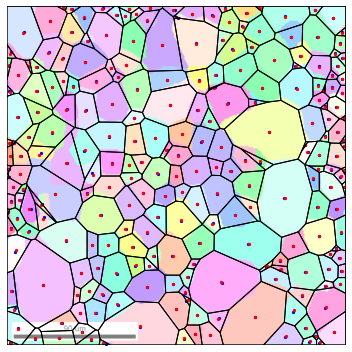

In [21]:
# Plot the fitted Laguerre diagram overlaid on the EBSD image
f, ax = plt.subplots(figsize=(5,5),layout='tight')
w, c = solve_OT_problem(t/(t-1)*b-xt_history[-1],v,OmegaEBSD)
plot_cells(t/(t-1)*b-xt_history[-1],w,OmegaEBSD,ax)
ax.axis("off")
im = plt.imread('EBSD_image.png')
implot = ax.imshow(im,alpha=0.5,zorder=-1,extent=(0,box_size,0,box_size),origin='lower')
ax.invert_yaxis()
ax.scatter(b[:,0],b[:,1],color='b',s=5) # target centroids in blue
ax.scatter(c[:,0],c[:,1],color='r',s=5) # centroids of the recovered cells in red

plt.savefig('diagram_ebsd.png',dpi=300)

Text(0, 0.5, '$f(B^k) - f(B^*)$')

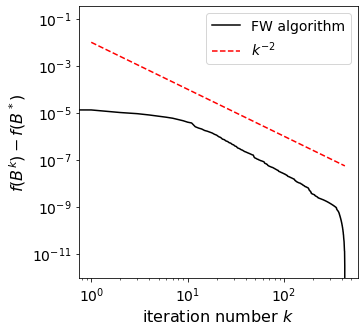

In [22]:
fig,ax = plt.subplots(figsize=(5,5))
ax.loglog(fun_history - np.min(fun_history),'k-',linewidth=1.5,label = 'FW algorithm')
ax.loglog(np.arange(len(fun_history))[1:],1/(np.arange(len(fun_history))[1:])**2/100,'r--',linewidth=1.5,label = '$k^{-2}$')
ax.legend()
ax.set_xlabel('iteration number $k$')
ax.set_ylabel('$f(B^k) - f(B^*)$')
